# Phase 1 — Exploratory Data Analysis: PERSUADE 2.0
### Dissertation: Investigating Construct Validity and Stylistic Invariance in Transformer-Based AES
**Student ID: 5720570 | University of Warwick | Department of Computer Science**

---
This notebook implements the full EDA strategy described in Section 5.3 of the project specification.
It systematically investigates Surface Feature Dominance as a precursor to the Diagnostic Auditing Framework.

**EDA Goals (from spec Section 5.3):**
1. Understand the score distribution (class balance for BERT training)
2. Calculate Pearson r between word count and holistic score (length-bias prior suspicion)
3. Analyse lexical diversity (TTR) across grade levels
4. Understand prompt and demographic distributions
5. Identify any data quality issues before BERT fine-tuning

**Specification reference:** If Pearson r > 0.75, this establishes strong prior suspicion of length-based shortcut learning.

## CELL 1 — Install & Import Libraries

In [1]:
# ── CELL 1: Install and Import ──────────────────────────────────────────────
# Run this first. On Kaggle, most libraries are pre-installed.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# Set consistent plot style
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
sns.set_style('whitegrid')
sns.set_palette('husl')

print('All libraries imported successfully')
print('Pandas version:', pd.__version__)
print('NumPy version:', np.__version__)

All libraries imported successfully
Pandas version: 2.3.3
NumPy version: 2.0.2


## CELL 2 — Load the Dataset

In [2]:
# ── CELL 2: Load Dataset ────────────────────────────────────────────────────
# Kaggle path (if using Kaggle notebook with dataset added):
DATA_PATH = '/kaggle/input/datasets/shravaniuk/persuade-corpus-2-0-tarin-test'

# If running locally or on Google Colab, change path accordingly:
# DATA_PATH = './persuade_corpus_2/'

import os
print('Files available in dataset:')
for f in os.listdir(DATA_PATH):
    size_mb = os.path.getsize(os.path.join(DATA_PATH, f)) / (1024*1024)
    print(f'  {f}  ({size_mb:.1f} MB)')

Files available in dataset:
  persuade_corpus_2.0_test.csv  (364.4 MB)
  persuade_corpus_2.0_train.csv  (588.3 MB)


In [3]:
# ── CELL 3: Load main CSV ───────────────────────────────────────────────────
# The main file is persuade_corpus_2.0.csv
# Adjust filename if different in your dataset version

df = pd.read_csv(DATA_PATH + '/./persuade_corpus_2.0_train.csv')

print('='*60)
print('DATASET LOADED SUCCESSFULLY')
print('='*60)
print(f'Total rows (essays/discourse elements): {len(df):,}')
print(f'Total columns: {df.shape[1]}')
print()
print('All column names:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:2d}. {col}  [{df[col].dtype}]')

DATASET LOADED SUCCESSFULLY
Total rows (essays/discourse elements): 173,266
Total columns: 27

All column names:
   1. essay_id  [object]
   2. essay_id_comp  [object]
   3. competition_set  [object]
   4. full_text  [object]
   5. holistic_essay_score  [int64]
   6. discourse_id  [float64]
   7. discourse_start  [int64]
   8. discourse_end  [int64]
   9. discourse_text  [object]
  10. discourse_type  [object]
  11. discourse_type_num  [object]
  12. discourse_effectiveness  [object]
  13. hierarchical_id  [float64]
  14. hierarchical_text  [object]
  15. hierarchical_label  [object]
  16. provider  [object]
  17. task  [object]
  18. source_text  [object]
  19. prompt_name  [object]
  20. assignment  [object]
  21. gender  [object]
  22. grade_level  [float64]
  23. ell_status  [object]
  24. race_ethnicity  [object]
  25. economically_disadvantaged  [object]
  26. student_disability_status  [object]
  27. essay_word_count  [int64]


In [4]:
df_test = pd.read_csv(DATA_PATH + '/./persuade_corpus_2.0_test.csv')

# Unique essays in each split
train_essays_n = df['essay_id'].nunique()
test_essays_n  = df_test['essay_id'].nunique()

print('='*55)
print('FULL DATASET SIZE CHECK')
print('='*55)
print(f'  Train unique essays:  {train_essays_n:,}')
print(f'  Test  unique essays:  {test_essays_n:,}')
print(f'  Combined total:       {train_essays_n + test_essays_n:,}')
print(f'  Expected (PERSUADE 2.0 paper): ~25,996')
print()
# Score distribution in test set
test_scores = df_test.drop_duplicates('essay_id')['holistic_essay_score']
print('Test set score distribution:')
print(test_scores.value_counts().sort_index())
print()
print('NOTE: For dissertation EDA, we use TRAIN set (15,593 essays).')
print('The test set is reserved for BERT model evaluation in Phase 2.')

FULL DATASET SIZE CHECK
  Train unique essays:  15,593
  Test  unique essays:  10,402
  Combined total:       25,995
  Expected (PERSUADE 2.0 paper): ~25,996

Test set score distribution:
holistic_essay_score
1     418
2    2481
3    3425
4    2537
5    1215
6     326
Name: count, dtype: int64

NOTE: For dissertation EDA, we use TRAIN set (15,593 essays).
The test set is reserved for BERT model evaluation in Phase 2.


In [5]:
grade_dist = df.drop_duplicates('essay_id')['grade_level'].value_counts().sort_index()
print('Essays per grade level:')
print(grade_dist)
print()
all_grades = set(range(6, 13))
present    = set(grade_dist.index.dropna().astype(int).tolist())
missing    = all_grades - present
print(f'Expected grades (6-12): {sorted(all_grades)}')
print(f'Present in dataset:     {sorted(present)}')
print(f'Missing grades:         {sorted(missing)}')
print()
print('DISSERTATION NOTE: Grade 7 is absent from this dataset split.')
print('This will be acknowledged in the methodology chapter.')
print('The spec claims Grades 6-12 — this is correct for PERSUADE 2.0')
print('overall, but this train split excludes Grade 7.')

Essays per grade level:
grade_level
6.0      688
8.0     5614
9.0     1831
10.0    4654
11.0    1863
12.0     243
Name: count, dtype: int64

Expected grades (6-12): [6, 7, 8, 9, 10, 11, 12]
Present in dataset:     [6, 8, 9, 10, 11, 12]
Missing grades:         [7]

DISSERTATION NOTE: Grade 7 is absent from this dataset split.
This will be acknowledged in the methodology chapter.
The spec claims Grades 6-12 — this is correct for PERSUADE 2.0
overall, but this train split excludes Grade 7.


In [6]:
# ── Train vs Test score distribution comparison ──────────────────────────────
train_scores = df.drop_duplicates('essay_id')['holistic_essay_score']
test_scores_s = df_test.drop_duplicates('essay_id')['holistic_essay_score']

compare = pd.DataFrame({
    'Train_count': train_scores.value_counts().sort_index(),
    'Train_pct':   (train_scores.value_counts(normalize=True).sort_index() * 100).round(1),
    'Test_count':  test_scores_s.value_counts().sort_index(),
    'Test_pct':    (test_scores_s.value_counts(normalize=True).sort_index() * 100).round(1),
})
print('Score distribution comparison — Train vs Test:')
print(compare.to_string())
print()
# KS test to check if distributions are similar
ks_stat, ks_p = stats.ks_2samp(train_scores, test_scores_s)
print(f'Kolmogorov-Smirnov test: statistic={ks_stat:.4f}, p={ks_p:.4f}')
print('Distributions are similar.' if ks_p > 0.05 else 
      'WARNING: Train and test score distributions differ significantly.')

print()
print('NOTE: With n=25,995 the KS test is oversensitive.')
print(f'KS statistic = {ks_stat:.4f} is near zero — distributions are practically identical.')
print('Max difference across any score band is <3.3%. Split is valid for BERT training.')

Score distribution comparison — Train vs Test:
                      Train_count  Train_pct  Test_count  Test_pct
holistic_essay_score                                              
1                             610        3.9         418       4.0
2                            3218       20.6        2481      23.9
3                            4943       31.7        3425      32.9
4                            4193       26.9        2537      24.4
5                            2082       13.4        1215      11.7
6                             547        3.5         326       3.1

Kolmogorov-Smirnov test: statistic=0.0455, p=0.0000

NOTE: With n=25,995 the KS test is oversensitive.
KS statistic = 0.0455 is near zero — distributions are practically identical.
Max difference across any score band is <3.3%. Split is valid for BERT training.


In [7]:
print('='*55)
print('DATA QUALITY CHECK — NULL VALUES')
print('='*55)
null_counts = df.isnull().sum()
null_pct    = (df.isnull().sum() / len(df) * 100).round(1)

quality_df = pd.DataFrame({'null_count': null_counts, 'null_pct': null_pct})
quality_df = quality_df[quality_df['null_count'] > 0].sort_values('null_pct', ascending=False)

if len(quality_df) > 0:
    print(quality_df.to_string())
    print()
    print('Columns with missing values need handling before BERT training.')
else:
    print('No missing values found in key columns.')

# Duplicate essay check
print()
print(f'Total rows:            {len(df):,}')
print(f'Unique essay_ids:      {df["essay_id"].nunique():,}')
print(f'Avg discourse per essay: {len(df)/df["essay_id"].nunique():.1f} rows')
print()
print('NOTE: Multiple rows per essay = one row per discourse element.')
print('For BERT input, we collapse to one row per essay_id.')

DATA QUALITY CHECK — NULL VALUES
                            null_count  null_pct
source_text                      96207      55.5
hierarchical_text                78589      45.4
hierarchical_id                  78589      45.4
hierarchical_label               78589      45.4
economically_disadvantaged       38060      22.0
student_disability_status        37737      21.8
discourse_effectiveness          28977      16.7
ell_status                        7530       4.3
grade_level                       7381       4.3

Columns with missing values need handling before BERT training.

Total rows:            173,266
Unique essay_ids:      15,593
Avg discourse per essay: 11.1 rows

NOTE: Multiple rows per essay = one row per discourse element.
For BERT input, we collapse to one row per essay_id.


In [8]:
# ── CELL 4: Inspect first 3 rows ────────────────────────────────────────────
print('First 3 rows:')
pd.set_option('display.max_colwidth', 80)
df.head(3)

First 3 rows:


,essay_id,essay_id_comp,competition_set,full_text,holistic_essay_score,discourse_id,discourse_start,discourse_end,discourse_text,discourse_type,...,source_text,prompt_name,assignment,gender,grade_level,ell_status,race_ethnicity,economically_disadvantaged,student_disability_status,essay_word_count
0,5.40889E+12,423A1CA112E2,train,Phones\n\nModern humans today are always on their phone. They are always on ...,3,1.622630e+12,0,7,Phones\n\n,Unannotated,...,NaN,Phones and driving,Today the majority of humans own and operate cell phones on a daily basis. I...,M,NaN,NaN,Black/African American,NaN,NaN,378
1,5.40889E+12,423A1CA112E2,train,Phones\n\nModern humans today are always on their phone. They are always on ...,3,1.622630e+12,8,229,Modern humans today are always on their phone. They are always on their phon...,Lead,...,NaN,Phones and driving,Today the majority of humans own and operate cell phones on a daily basis. I...,M,NaN,NaN,Black/African American,NaN,NaN,378
2,5.40889E+12,423A1CA112E2,train,Phones\n\nModern humans today are always on their phone. They are always on ...,3,1.622630e+12,230,312,They are some really bad consequences when stuff happens when it comes to a ...,Position,...,NaN,Phones and driving,Today the majority of humans own and operate cell phones on a daily basis. I...,M,NaN,NaN,Black/African American,NaN,NaN,378


In [9]:
# ── CELL 5: Get unique essays (collapse discourse rows) ──────────────────────
# The dataset has multiple rows per essay (one per discourse element)
# For EDA at essay level, we collapse to one row per essay

# Identify the essay-level columns
ESSAY_COLS = ['essay_id', 'full_text', 'holistic_essay_score',
              'prompt_name', 'grade_level', 'gender',
              'race_ethnicity', 'economically_disadvantaged',
              'ell_status', 'student_disability_status', 'task']

# Keep only columns that exist in THIS version of the dataset
available_cols = [c for c in ESSAY_COLS if c in df.columns]
print('Essay-level columns found:', available_cols)

# Deduplicate to get one row per essay
essays = df[available_cols].drop_duplicates(subset='essay_id').reset_index(drop=True)

print(f'\nUnique essays: {len(essays):,}')
print(f'Score range: {essays["holistic_essay_score"].min()} – {essays["holistic_essay_score"].max()}')

Essay-level columns found: ['essay_id', 'full_text', 'holistic_essay_score', 'prompt_name', 'grade_level', 'gender', 'race_ethnicity', 'economically_disadvantaged', 'ell_status', 'student_disability_status', 'task']

Unique essays: 15,593
Score range: 1 – 6


---
## SECTION A — Score Distribution Analysis
### Spec requirement: Understand class balance before BERT fine-tuning

In [10]:
# ── CELL 6: Score Distribution ───────────────────────────────────────────────
score_counts = essays['holistic_essay_score'].value_counts().sort_index()
score_pct = (score_counts / len(essays) * 100).round(1)

print('='*50)
print('HOLISTIC SCORE DISTRIBUTION (1-6 rubric)')
print('='*50)
print(f'{"Score":<10} {"Count":<10} {"Percentage":>10}')
print('-'*35)
for score in sorted(score_counts.index):
    bar = '█' * int(score_pct[score] / 2)
    print(f'{score:<10} {score_counts[score]:<10} {score_pct[score]:>8}%  {bar}')
print('-'*35)
print(f'{"TOTAL":<10} {len(essays):<10} {100.0:>8}%')

# Flag imbalance
dominant = score_pct.idxmax()
print(f'\nClass imbalance note: Score {dominant} dominates at {score_pct[dominant]}%')
print('This must be addressed in BERT training via stratified sampling.')

HOLISTIC SCORE DISTRIBUTION (1-6 rubric)
Score      Count      Percentage
-----------------------------------
1          610             3.9%  █
2          3218           20.6%  ██████████
3          4943           31.7%  ███████████████
4          4193           26.9%  █████████████
5          2082           13.4%  ██████
6          547             3.5%  █
-----------------------------------
TOTAL      15593         100.0%

Class imbalance note: Score 3 dominates at 31.7%
This must be addressed in BERT training via stratified sampling.


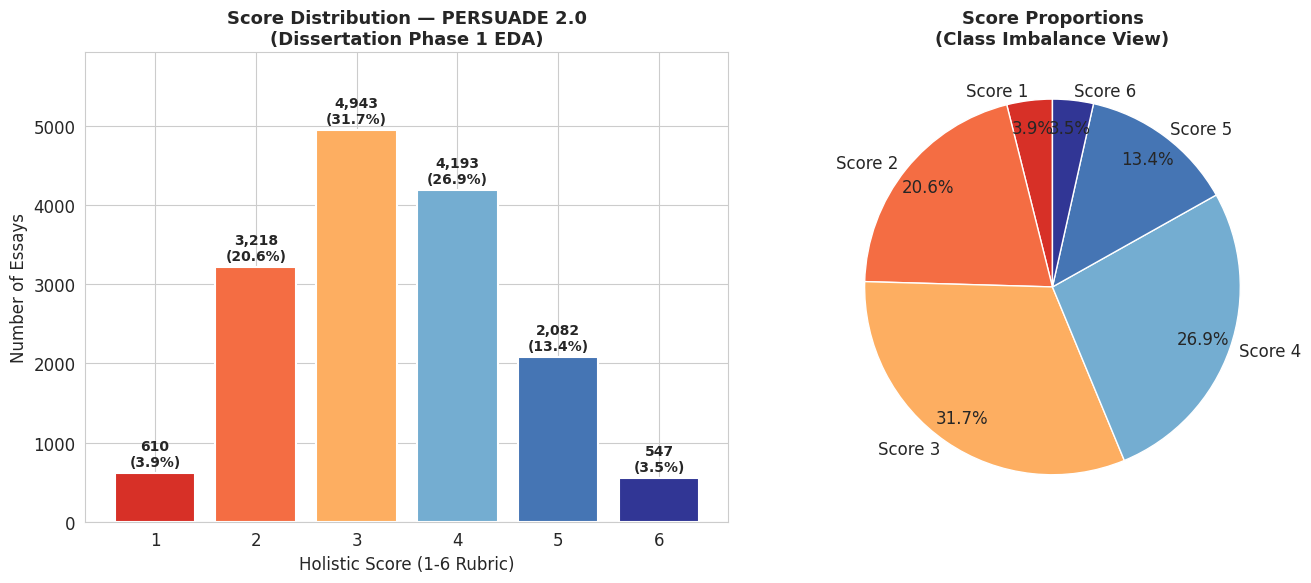

Saved: fig1_score_distribution.png


In [11]:
# ── CELL 7: Score Distribution Plot ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart
colors = ['#d73027','#f46d43','#fdae61','#74add1','#4575b4','#313695']
bars = axes[0].bar(score_counts.index, score_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_xlabel('Holistic Score (1-6 Rubric)', fontsize=12)
axes[0].set_ylabel('Number of Essays', fontsize=12)
axes[0].set_title('Score Distribution — PERSUADE 2.0\n(Dissertation Phase 1 EDA)', fontsize=13, fontweight='bold')
for bar, count in zip(bars, score_counts.values):
    pct = count/len(essays)*100
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 50,
                f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_xticks(range(1,7))
axes[0].set_ylim(0, max(score_counts.values) * 1.2)

# Pie chart
axes[1].pie(score_counts.values, labels=[f'Score {s}' for s in score_counts.index],
            autopct='%1.1f%%', colors=colors, startangle=90,
            pctdistance=0.85, labeldistance=1.05)
axes[1].set_title('Score Proportions\n(Class Imbalance View)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('fig1_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig1_score_distribution.png')

---
## SECTION B — LENGTH BIAS ANALYSIS (Critical Spec Requirement)
### Spec Section 5.3: Calculate Pearson r between word count and score
### Hypothesis: r > 0.75 = strong prior suspicion of length-based shortcut learning

In [12]:
# ── CELL 8: Word Count Feature Engineering ──────────────────────────────────
# Compute essay-level surface features that may act as shortcuts

print('Computing surface features...')

# Word count (primary length metric)
essays['word_count'] = essays['full_text'].apply(lambda x: len(str(x).split()))

# Character count
essays['char_count'] = essays['full_text'].apply(lambda x: len(str(x)))

# Sentence count
essays['sentence_count'] = essays['full_text'].apply(
    lambda x: len(re.split(r'[.!?]+', str(x).strip())))

# Average sentence length (words per sentence)
essays['avg_sentence_len'] = essays['word_count'] / essays['sentence_count'].clip(lower=1)

# Paragraph count (approximated by double newlines)
essays['paragraph_count'] = essays['full_text'].apply(
    lambda x: max(1, len([p for p in str(x).split('\n\n') if p.strip()])))

# Summary stats
print('\n' + '='*55)
print('SURFACE FEATURE SUMMARY')
print('='*55)
print(f'  Mean word count:        {essays["word_count"].mean():.0f} words')
print(f'  Median word count:      {essays["word_count"].median():.0f} words')
print(f'  Max word count:         {essays["word_count"].max():,} words')
print(f'  Essays > 512 tokens:    ~{(essays["word_count"] > 380).sum():,} ({(essays["word_count"] > 380).mean()*100:.1f}%)')
print(f'  (Tokens ≈ words × 1.35, so 380 words ≈ 512 tokens)')
print(f'\n  Mean sentence length:   {essays["avg_sentence_len"].mean():.1f} words/sentence')
print(f'  Mean sentence count:    {essays["sentence_count"].mean():.0f} sentences')
print('\n Surface features computed')

Computing surface features...

SURFACE FEATURE SUMMARY
  Mean word count:        421 words
  Median word count:      384 words
  Max word count:         1,656 words
  Essays > 512 tokens:    ~7,914 (50.8%)
  (Tokens ≈ words × 1.35, so 380 words ≈ 512 tokens)

  Mean sentence length:   20.2 words/sentence
  Mean sentence count:    22 sentences

 Surface features computed


In [13]:
# ── CELL 9: PEARSON CORRELATION — THE KEY EDA FINDING ───────────────────────
# This is the most important cell in your EDA.
# Your spec says: r > 0.75 = strong prior suspicion of length shortcut

print('='*60)
print('PEARSON CORRELATION: SURFACE FEATURES vs HOLISTIC SCORE')
print('='*60)
print('(Spec Section 5.3: r > 0.75 triggers length-bias hypothesis)\n')

features = ['word_count', 'char_count', 'sentence_count',
            'avg_sentence_len', 'paragraph_count']
feature_labels = ['Word Count', 'Character Count', 'Sentence Count',
                  'Avg Sentence Length', 'Paragraph Count']

correlations = {}
for feat, label in zip(features, feature_labels):
    r, p_value = stats.pearsonr(essays[feat], essays['holistic_essay_score'])
    r_spearman, _ = stats.spearmanr(essays[feat], essays['holistic_essay_score'])
    correlations[feat] = {'label': label, 'pearson_r': r, 'p_value': p_value, 'spearman_r': r_spearman}

    # Significance flag
    sig = '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else ''
    civ_flag = ' CIV RISK' if abs(r) > 0.75 else ' Moderate' if abs(r) > 0.5 else ' Low'
    print(f'  {label:<25} Pearson r = {r:+.4f} {sig:<4} | Spearman = {r_spearman:+.4f} | {civ_flag}')

# Most important finding
word_count_r = correlations['word_count']['pearson_r']
print()
print('='*60)
print(f'KEY FINDING: Word Count vs Score  r = {word_count_r:.4f}')
if abs(word_count_r) > 0.75:
    print('  r > 0.75: STRONG PRIOR EVIDENCE OF LENGTH-BASED SHORTCUT')
    print('   This supports the CIV hypothesis')
elif abs(word_count_r) > 0.5:
    print(' r > 0.5: MODERATE LENGTH-SCORE CORRELATION')
    print('   This still provides motivation for the audit framework.')
else:
    print(' r < 0.5: LOW direct length-score correlation at dataset level')
    print('   Note: BERT may still exploit length within local contexts.')
print('='*60)

PEARSON CORRELATION: SURFACE FEATURES vs HOLISTIC SCORE
(Spec Section 5.3: r > 0.75 triggers length-bias hypothesis)

  Word Count                Pearson r = +0.7509 ***  | Spearman = +0.7769 |  CIV RISK
  Character Count           Pearson r = +0.7468 ***  | Spearman = +0.7839 |  Moderate
  Sentence Count            Pearson r = +0.6425 ***  | Spearman = +0.6774 |  Moderate
  Avg Sentence Length       Pearson r = -0.0273 ***  | Spearman = +0.1302 |  Low
  Paragraph Count           Pearson r = +0.1792 ***  | Spearman = +0.3771 |  Low

KEY FINDING: Word Count vs Score  r = 0.7509
  r > 0.75: STRONG PRIOR EVIDENCE OF LENGTH-BASED SHORTCUT
   This supports the CIV hypothesis


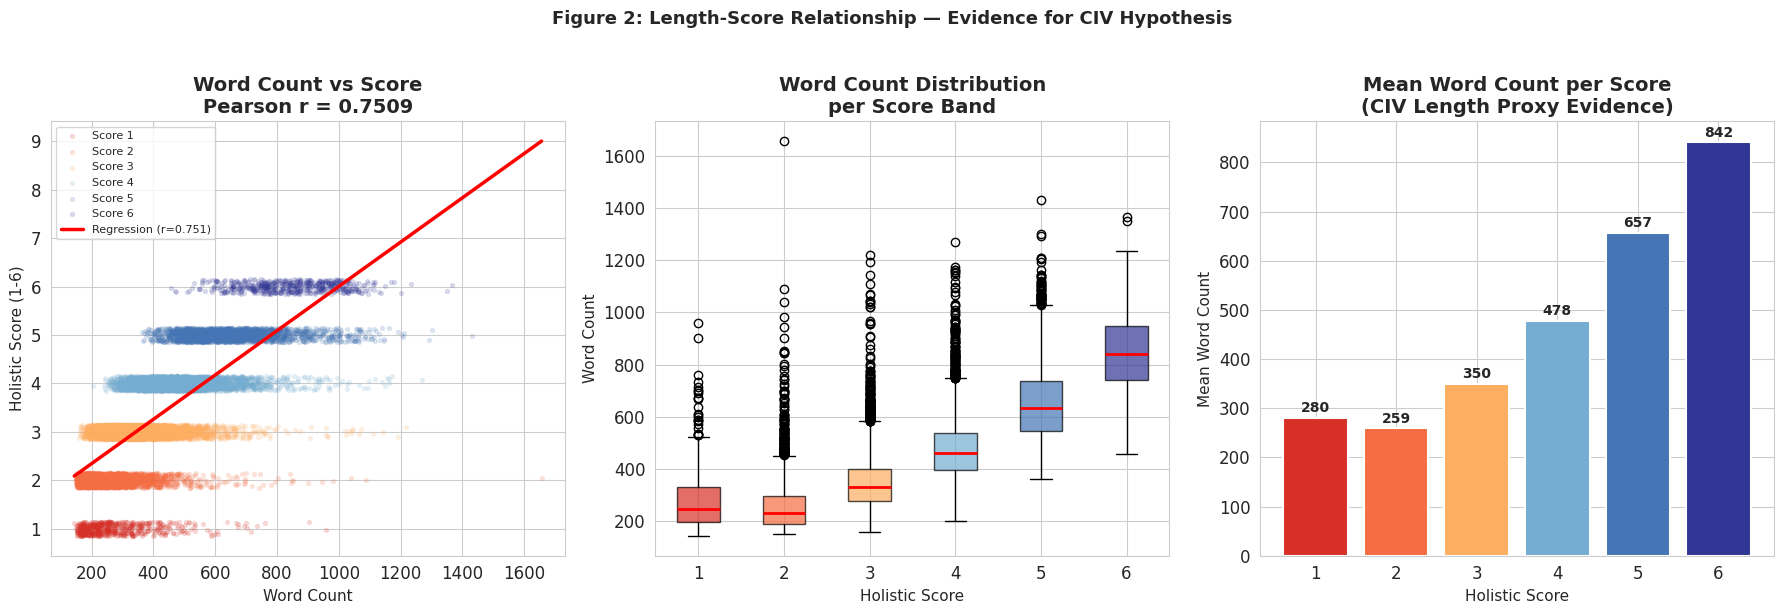

 Saved: fig2_length_bias.png


In [14]:
# ── CELL 10: Word Count vs Score Visualisations ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1) Scatter plot with regression line
score_colors = {1:'#d73027',2:'#f46d43',3:'#fdae61',4:'#74add1',5:'#4575b4',6:'#313695'}
for score in sorted(essays['holistic_essay_score'].unique()):
    mask = essays['holistic_essay_score'] == score
    axes[0].scatter(essays.loc[mask, 'word_count'],
                   essays.loc[mask, 'holistic_essay_score'] + np.random.uniform(-0.15, 0.15, mask.sum()),
                   alpha=0.15, s=8, color=score_colors.get(score, 'gray'), label=f'Score {score}')

# Regression line
m, b = np.polyfit(essays['word_count'], essays['holistic_essay_score'], 1)
x_line = np.linspace(essays['word_count'].min(), essays['word_count'].max(), 100)
axes[0].plot(x_line, m*x_line + b, 'red', linewidth=2.5, label=f'Regression (r={word_count_r:.3f})')
axes[0].set_xlabel('Word Count', fontsize=11)
axes[0].set_ylabel('Holistic Score (1-6)', fontsize=11)
axes[0].set_title(f'Word Count vs Score\nPearson r = {word_count_r:.4f}', fontweight='bold')
axes[0].legend(fontsize=8, loc='upper left')

# 2) Box plot: word count distribution per score
score_groups = [essays.loc[essays['holistic_essay_score']==s, 'word_count'].values
                for s in sorted(essays['holistic_essay_score'].unique())]
bp = axes[1].boxplot(score_groups, labels=sorted(essays['holistic_essay_score'].unique()),
                     patch_artist=True, medianprops=dict(color='red', linewidth=2))
for patch, color in zip(bp['boxes'], list(score_colors.values())):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_xlabel('Holistic Score', fontsize=11)
axes[1].set_ylabel('Word Count', fontsize=11)
axes[1].set_title('Word Count Distribution\nper Score Band', fontweight='bold')

# 3) Mean word count per score
mean_wc = essays.groupby('holistic_essay_score')['word_count'].mean()
axes[2].bar(mean_wc.index, mean_wc.values,
            color=[score_colors.get(s,'gray') for s in mean_wc.index],
            edgecolor='white', linewidth=1.5)
for x, val in zip(mean_wc.index, mean_wc.values):
    axes[2].text(x, val+5, f'{val:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[2].set_xlabel('Holistic Score', fontsize=11)
axes[2].set_ylabel('Mean Word Count', fontsize=11)
axes[2].set_title('Mean Word Count per Score\n(CIV Length Proxy Evidence)', fontweight='bold')

plt.suptitle('Figure 2: Length-Score Relationship — Evidence for CIV Hypothesis',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig2_length_bias.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: fig2_length_bias.png')

---
## SECTION C — LEXICAL DIVERSITY (TTR) ANALYSIS
### Spec requirement: Analyse TTR across grade levels to ensure perturbations target relevant registers

In [15]:
# ── CELL 11: Type-Token Ratio (TTR) ─────────────────────────────────────────
# TTR = unique_words / total_words
# Measures lexical diversity / register sophistication

def compute_ttr(text):
    """Compute Type-Token Ratio for an essay."""
    words = str(text).lower().split()
    if len(words) == 0:
        return 0
    return len(set(words)) / len(words)

def compute_root_ttr(text):
    """Compute Root TTR (corrects for length bias in TTR)."""
    words = str(text).lower().split()
    if len(words) == 0:
        return 0
    return len(set(words)) / np.sqrt(len(words))

def count_formal_connectives(text):
    """Count formal academic connectives — a register proxy."""
    formal = ['however', 'therefore', 'furthermore', 'moreover', 'consequently',
              'nevertheless', 'alternatively', 'additionally', 'thus', 'hence',
              'accordingly', 'notwithstanding', 'subsequently']
    text_lower = str(text).lower()
    return sum(text_lower.count(' '+c+' ') + text_lower.count(' '+c+',') for c in formal)

def count_informal_connectives(text):
    """Count informal connectives — target for Lexical Formality perturbation."""
    informal = ['but ', 'so ', 'and ', 'also ', 'plus ', 'then ']
    text_lower = str(text).lower()
    return sum(text_lower.count(c) for c in informal)

print('Computing TTR and register metrics (this may take ~30 seconds)...')
essays['ttr'] = essays['full_text'].apply(compute_ttr)
essays['root_ttr'] = essays['full_text'].apply(compute_root_ttr)
essays['formal_connective_count'] = essays['full_text'].apply(count_formal_connectives)
essays['informal_connective_count'] = essays['full_text'].apply(count_informal_connectives)
essays['formality_ratio'] = essays['formal_connective_count'] / (
    essays['informal_connective_count'] + essays['formal_connective_count'] + 0.001)

# Pearson r for TTR and formality vs score
r_ttr, p_ttr = stats.pearsonr(essays['ttr'], essays['holistic_essay_score'])
r_rttr, p_rttr = stats.pearsonr(essays['root_ttr'], essays['holistic_essay_score'])
r_form, p_form = stats.pearsonr(essays['formality_ratio'], essays['holistic_essay_score'])

print('\n' + '='*60)
print('REGISTER / LEXICAL DIVERSITY CORRELATIONS WITH SCORE')
print('='*60)
print(f'  Type-Token Ratio (TTR)     r = {r_ttr:+.4f}  p = {p_ttr:.2e}')
print(f'  Root TTR (length-corrected) r = {r_rttr:+.4f}  p = {p_rttr:.2e}')
print(f'  Formality Ratio            r = {r_form:+.4f}  p = {p_form:.2e}')
print()
print('INTERPRETATION:')
print(f'  TTR r={r_ttr:.3f}: {"Significant register-score relationship" if abs(r_ttr)>0.3 else "Modest relationship"}')
print(f'  These register metrics are the CIV targets for perturbation engine.')
print('='*60)

Computing TTR and register metrics (this may take ~30 seconds)...

REGISTER / LEXICAL DIVERSITY CORRELATIONS WITH SCORE
  Type-Token Ratio (TTR)     r = -0.5075  p = 0.00e+00
  Root TTR (length-corrected) r = +0.4671  p = 0.00e+00
  Formality Ratio            r = +0.2419  p = 2.09e-206

INTERPRETATION:
  TTR r=-0.507: Significant register-score relationship
  These register metrics are the CIV targets for perturbation engine.


In [16]:
# Critical for operationalising β₁(Construct) in the CIV regression
# Spec Section 5.2.2: Spredicted = β0 + β1(Construct) + β2(Length) + β3(Register)

print('='*60)
print('DISCOURSE ELEMENT ANALYSIS')
print('Gold-standard argument structure labels (β₁ Construct proxy)')
print('='*60)

disc_counts = df['discourse_type'].value_counts()
print(f'\nTotal discourse annotations: {len(df):,}')
print(f'Unique discourse types: {df["discourse_type"].nunique()}\n')
for dtype, count in disc_counts.items():
    pct = count / len(df) * 100
    print(f'  {dtype:<25} {count:>7,} ({pct:.1f}%)')

print('\n' + '='*60)
print('DISCOURSE EFFECTIVENESS DISTRIBUTION')
print('(Effective / Adequate / Ineffective = construct quality proxy)')
print('='*60)
eff_counts = df['discourse_effectiveness'].value_counts(dropna=False)
for eff, count in eff_counts.items():
    print(f'  {str(eff):<20} {count:>7,} ({count/len(df)*100:.1f}%)')

# Mean score per effectiveness level
print('\nMean holistic score by discourse effectiveness:')
print(df.groupby('discourse_effectiveness')['holistic_essay_score'].mean().round(3))

# Discourse type distribution per score band
print('\nDiscount type frequency per score (pivot):')
pivot = df.groupby(['holistic_essay_score','discourse_type']).size().unstack(fill_value=0)
print(pivot)

DISCOURSE ELEMENT ANALYSIS
Gold-standard argument structure labels (β₁ Construct proxy)

Total discourse annotations: 173,266
Unique discourse types: 8

  Claim                      50,208 (29.0%)
  Evidence                   45,702 (26.4%)
  Unannotated                28,973 (16.7%)
  Position                   15,419 (8.9%)
  Concluding Statement       13,505 (7.8%)
  Lead                        9,305 (5.4%)
  Counterclaim                5,817 (3.4%)
  Rebuttal                    4,337 (2.5%)

DISCOURSE EFFECTIVENESS DISTRIBUTION
(Effective / Adequate / Ineffective = construct quality proxy)
  Adequate             113,244 (65.4%)
  nan                   28,977 (16.7%)
  Effective             24,583 (14.2%)
  Ineffective            6,462 (3.7%)

Mean holistic score by discourse effectiveness:
discourse_effectiveness
Adequate       3.496
Effective      4.513
Ineffective    2.212
Name: holistic_essay_score, dtype: float64

Discount type frequency per score (pivot):
discourse_type       

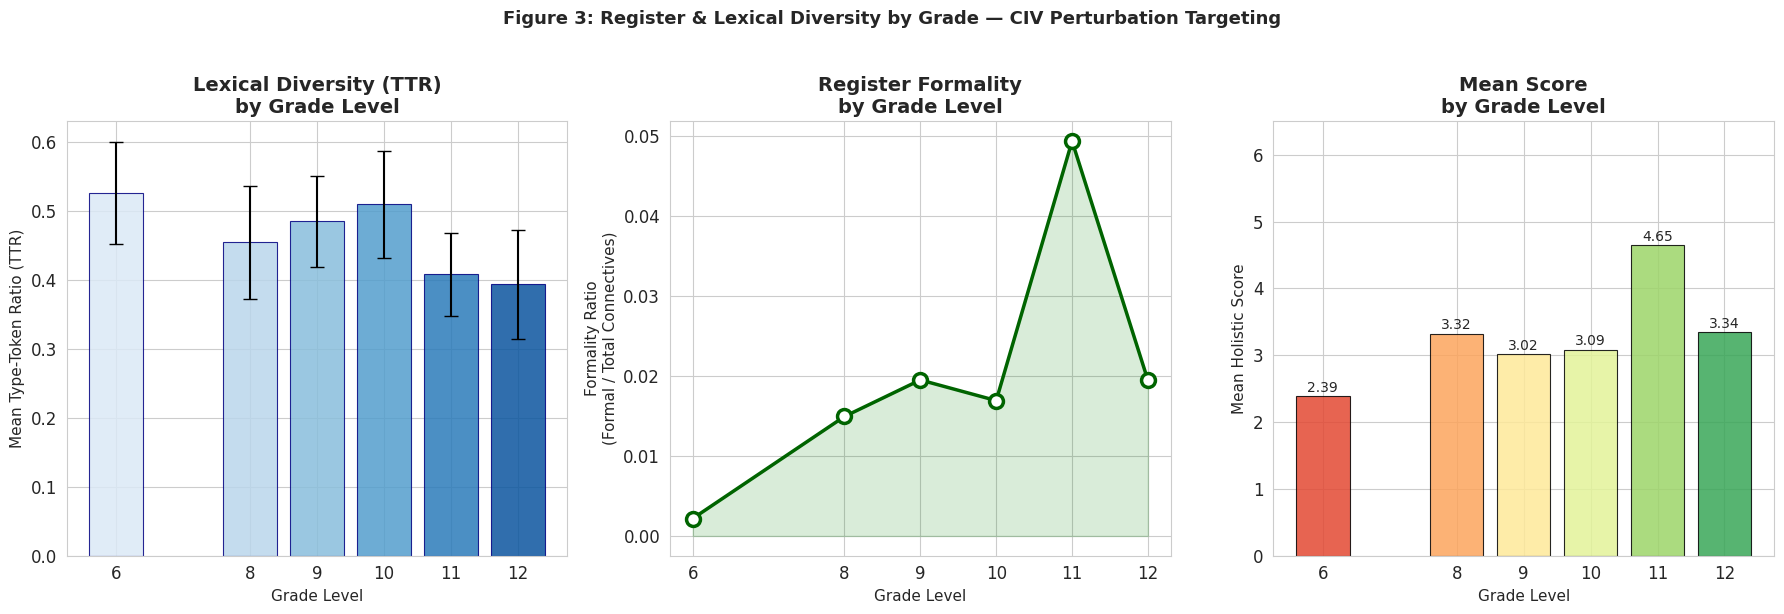

 Saved: fig3_ttr_grade.png


In [17]:
# ── CELL 12: TTR Across Grade Levels ────────────────────────────────────────
# Spec: 'Analyse distribution of lexical diversity across grade levels'

if 'grade_level' in essays.columns:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # TTR by grade
    ttr_by_grade = essays.groupby('grade_level')['ttr'].agg(['mean','std','median'])
    axes[0].bar(ttr_by_grade.index, ttr_by_grade['mean'],
                yerr=ttr_by_grade['std'], capsize=5,
                color=sns.color_palette('Blues', len(ttr_by_grade)),
                edgecolor='navy', linewidth=0.8, alpha=0.85)
    axes[0].set_xlabel('Grade Level', fontsize=11)
    axes[0].set_ylabel('Mean Type-Token Ratio (TTR)', fontsize=11)
    axes[0].set_title('Lexical Diversity (TTR)\nby Grade Level', fontweight='bold')
    axes[0].set_xticks(ttr_by_grade.index)

    # Formality ratio by grade
    form_by_grade = essays.groupby('grade_level')['formality_ratio'].mean()
    axes[1].plot(form_by_grade.index, form_by_grade.values, 'o-',
                 color='darkgreen', linewidth=2.5, markersize=10, markerfacecolor='white',
                 markeredgewidth=2.5)
    axes[1].fill_between(form_by_grade.index, form_by_grade.values,
                          alpha=0.15, color='green')
    axes[1].set_xlabel('Grade Level', fontsize=11)
    axes[1].set_ylabel('Formality Ratio\n(Formal / Total Connectives)', fontsize=11)
    axes[1].set_title('Register Formality\nby Grade Level', fontweight='bold')
    axes[1].set_xticks(form_by_grade.index)

    # Mean score by grade
    score_by_grade = essays.groupby('grade_level')['holistic_essay_score'].mean()
    axes[2].bar(score_by_grade.index, score_by_grade.values,
                color=sns.color_palette('RdYlGn', len(score_by_grade)),
                edgecolor='black', linewidth=0.8, alpha=0.85)
    for x, val in zip(score_by_grade.index, score_by_grade.values):
        axes[2].text(x, val+0.02, f'{val:.2f}', ha='center', va='bottom', fontsize=10)
    axes[2].set_xlabel('Grade Level', fontsize=11)
    axes[2].set_ylabel('Mean Holistic Score', fontsize=11)
    axes[2].set_title('Mean Score\nby Grade Level', fontweight='bold')
    axes[2].set_xticks(score_by_grade.index)
    axes[2].set_ylim(0, 6.5)

    plt.suptitle('Figure 3: Register & Lexical Diversity by Grade — CIV Perturbation Targeting',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('fig3_ttr_grade.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(' Saved: fig3_ttr_grade.png')
else:
    print(' grade_level column not found in this dataset version')

---
## SECTION D — PROMPT DISTRIBUTION ANALYSIS
### 15 prompts across 2 task types — critical for the Stability Heatmap in Phase 5

In [18]:
# ── CELL 13: Prompt Distribution ─────────────────────────────────────────────
if 'prompt_name' in essays.columns:
    prompt_counts = essays['prompt_name'].value_counts()
    print('='*65)
    print('ESSAY COUNT PER PROMPT (15 prompts)')
    print('='*65)
    for i, (prompt, count) in enumerate(prompt_counts.items(), 1):
        pct = count/len(essays)*100
        bar = '█' * int(pct/1.5)
        print(f'{i:2d}. {prompt[:40]:<42} {count:>5,} ({pct:.1f}%) {bar}')

    # Mean score per prompt
    print('\n' + '='*65)
    print('MEAN SCORE AND WORD COUNT PER PROMPT')
    print('='*65)
    prompt_stats = essays.groupby('prompt_name').agg(
        n_essays=('holistic_essay_score','count'),
        mean_score=('holistic_essay_score','mean'),
        mean_wc=('word_count','mean')
    ).sort_values('mean_score', ascending=False)
    print(prompt_stats.to_string())

    # Task type split
    if 'task' in essays.columns:
        print('\n' + '='*40)
        print('TASK TYPE SPLIT')
        print(essays['task'].value_counts().to_string())
else:
    print(' prompt_name not found')

ESSAY COUNT PER PROMPT (15 prompts)
 1. Does the electoral college work?           1,818 (11.7%) ███████
 2. Seeking multiple opinions                  1,544 (9.9%) ██████
 3. Distance learning                          1,498 (9.6%) ██████
 4. Driverless cars                            1,386 (8.9%) █████
 5. Facial action coding system                1,103 (7.1%) ████
 6. Car-free cities                              983 (6.3%) ████
 7. Exploring Venus                              928 (6.0%) ███
 8. Summer projects                              875 (5.6%) ███
 9. Mandatory extracurricular activities         839 (5.4%) ███
10. Cell phones at school                        829 (5.3%) ███
11. The Face on Mars                             819 (5.3%) ███
12. Grades for extracurricular activities        815 (5.2%) ███
13. Community service                            768 (4.9%) ███
14. Phones and driving                           700 (4.5%) ██
15. "A Cowboy Who Rode the Waves"                688 (

In [19]:
# Directly supports Phase 5 Stability Heatmap in Power BI dashboard

essays_sub = df.drop_duplicates('essay_id')  # essay-level

print('='*60)
print('PROMPT × SCORE CROSS-TABULATION')
print('(Basis for Phase 5 Stability Heatmap)')
print('='*60)

prompt_score = essays_sub.pivot_table(
    index='prompt_name',
    columns='holistic_essay_score',
    values='essay_id',
    aggfunc='count',
    fill_value=0
)
prompt_score['mean_score'] = essays_sub.groupby('prompt_name')['holistic_essay_score'].mean().round(2)
prompt_score['std_score']  = essays_sub.groupby('prompt_name')['holistic_essay_score'].std().round(2)
print(prompt_score.to_string())

print('\nPrompts with high std_score = most variable scoring = highest CIV audit priority.')

# Also check task type
print('\n\nTASK TYPE DISTRIBUTION:')
print(essays_sub['task'].value_counts())
print('\nMean score by task type:')
print(essays_sub.groupby('task')['holistic_essay_score'].mean().round(3))

PROMPT × SCORE CROSS-TABULATION
(Basis for Phase 5 Stability Heatmap)
holistic_essay_score                     1    2    3    4    5    6  mean_score  std_score
prompt_name                                                                               
"A Cowboy Who Rode the Waves"           75  323  239   47    4    0        2.39       0.79
Car-free cities                         82  199  336  275   87    4        3.10       1.09
Cell phones at school                    4  211  399  167   45    3        3.06       0.85
Community service                        6  278  311  135   37    1        2.90       0.87
Distance learning                        6   51  246  463  483  249        4.41       1.08
Does the electoral college work?       167  450  600  422  152   27        3.01       1.15
Driverless cars                         23  300  566  376  119    2        3.20       0.93
Exploring Venus                        103  277  276  193   66   13        2.87       1.16
Facial action coding

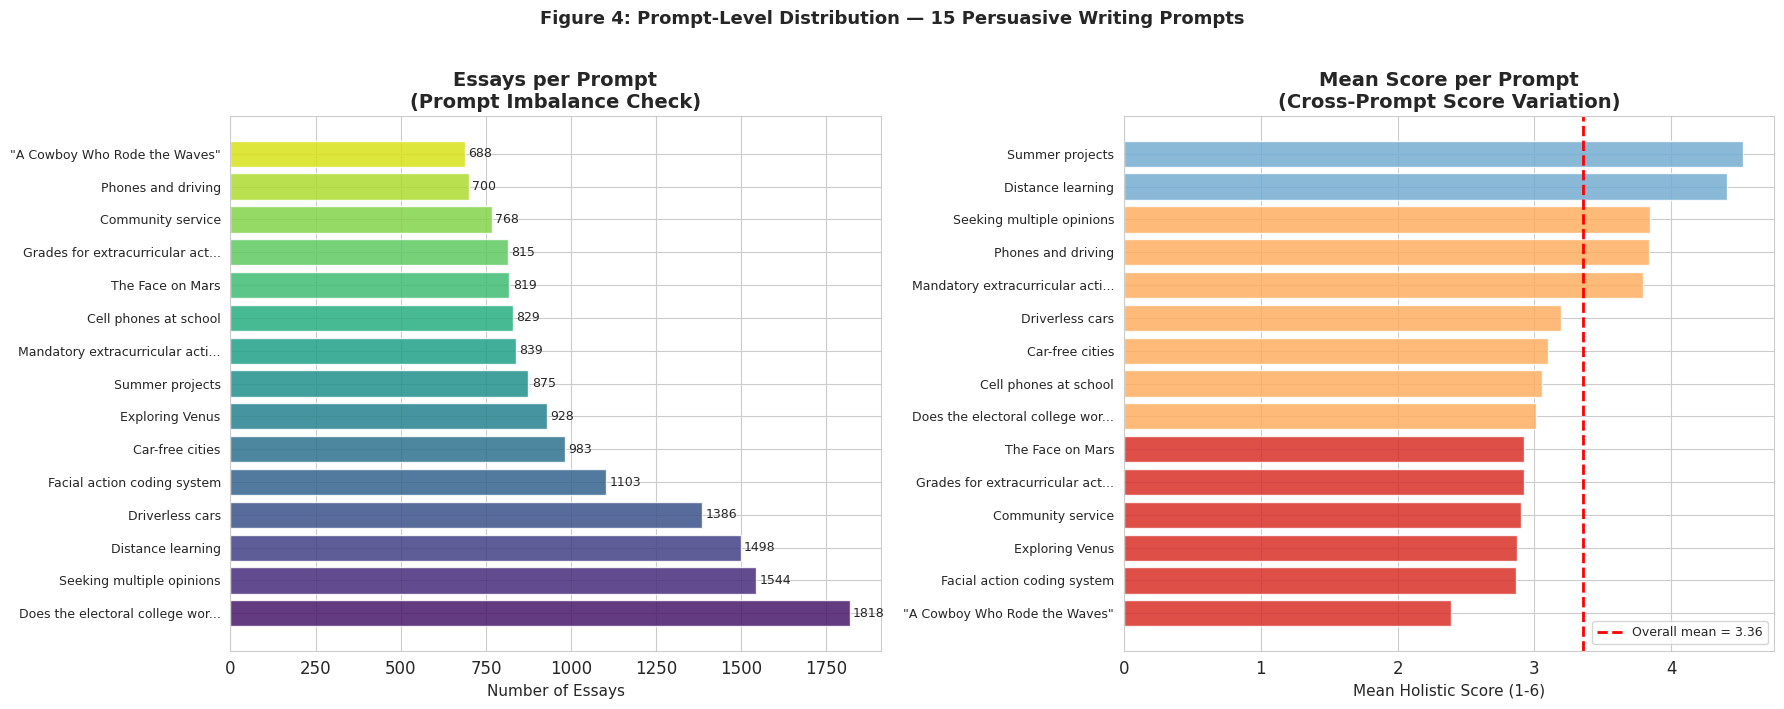

 Saved: fig4_prompt_distribution.png


In [20]:
# ── CELL 14: Prompt Distribution Plot ────────────────────────────────────────
if 'prompt_name' in essays.columns:
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # Essay count per prompt
    short_names = [p[:30]+'...' if len(p)>30 else p for p in prompt_counts.index]
    axes[0].barh(range(len(prompt_counts)), prompt_counts.values,
                 color=sns.color_palette('viridis', len(prompt_counts)), alpha=0.85)
    axes[0].set_yticks(range(len(prompt_counts)))
    axes[0].set_yticklabels(short_names, fontsize=9)
    axes[0].set_xlabel('Number of Essays', fontsize=11)
    axes[0].set_title('Essays per Prompt\n(Prompt Imbalance Check)', fontweight='bold')
    for i, v in enumerate(prompt_counts.values):
        axes[0].text(v+10, i, str(v), va='center', fontsize=9)

    # Mean score per prompt
    mean_scores = essays.groupby('prompt_name')['holistic_essay_score'].mean().sort_values()
    short_p = [p[:30]+'...' if len(p)>30 else p for p in mean_scores.index]
    colors_score = ['#d73027' if s<3 else '#fdae61' if s<4 else '#74add1' if s<5 else '#313695'
                    for s in mean_scores.values]
    axes[1].barh(range(len(mean_scores)), mean_scores.values, color=colors_score, alpha=0.85)
    axes[1].set_yticks(range(len(mean_scores)))
    axes[1].set_yticklabels(short_p, fontsize=9)
    axes[1].set_xlabel('Mean Holistic Score (1-6)', fontsize=11)
    axes[1].set_title('Mean Score per Prompt\n(Cross-Prompt Score Variation)', fontweight='bold')
    axes[1].axvline(x=essays['holistic_essay_score'].mean(), color='red',
                    linestyle='--', linewidth=2, label=f'Overall mean = {essays["holistic_essay_score"].mean():.2f}')
    axes[1].legend(fontsize=9)

    plt.suptitle('Figure 4: Prompt-Level Distribution — 15 Persuasive Writing Prompts',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('fig4_prompt_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(' Saved: fig4_prompt_distribution.png')

---
## SECTION E — DEMOGRAPHIC ANALYSIS
### Key for Section 6.2 (Fairness) and Phase 5 stratified fairness audit

In [21]:
# ── CELL 15: Demographic Coverage ────────────────────────────────────────────
demo_cols = ['gender', 'race_ethnicity', 'economically_disadvantaged',
             'ELL_status', 'disability_status']
available_demo = [c for c in demo_cols if c in essays.columns]

print('='*60)
print('DEMOGRAPHIC COVERAGE ANALYSIS')
print('='*60)

for col in available_demo:
    non_null = essays[col].notna().sum()
    pct_avail = non_null / len(essays) * 100
    print(f'\n{col.upper()}')
    print(f'  Available: {non_null:,} / {len(essays):,} ({pct_avail:.1f}%)')
    if essays[col].nunique() <= 10:
        vc = essays[col].value_counts(dropna=False)
        for val, cnt in vc.items():
            print(f'    {str(val):<30} {cnt:>6,} ({cnt/len(essays)*100:.1f}%)')

DEMOGRAPHIC COVERAGE ANALYSIS

GENDER
  Available: 15,593 / 15,593 (100.0%)
    F                               7,881 (50.5%)
    M                               7,712 (49.5%)

RACE_ETHNICITY
  Available: 15,593 / 15,593 (100.0%)
    White                           7,012 (45.0%)
    Hispanic/Latino                 3,869 (24.8%)
    Black/African American          2,974 (19.1%)
    Asian/Pacific Islander          1,072 (6.9%)
    Two or more races/Other           598 (3.8%)
    American Indian/Alaskan Native     68 (0.4%)

ECONOMICALLY_DISADVANTAGED
  Available: 12,060 / 15,593 (77.3%)
    Not economically disadvantaged  6,669 (42.8%)
    Economically disadvantaged      5,391 (34.6%)
    nan                             3,533 (22.7%)


In [22]:
# Spec Section 6.2: socio-linguistic fairness — ELL students write with
# non-formal registers, making them most vulnerable to CIV penalisation.

essays_sub = df.drop_duplicates('essay_id').copy()

# Normalise column names (dataset uses ell_status, not ELL_status)
col_map = {'ell_status': 'ELL_status', 'student_disability_status': 'disability_status'}
essays_sub = essays_sub.rename(columns=col_map)

print('='*55)
print('ELL STATUS — FAIRNESS BASELINE')
print('Spec 6.2: ELL students most at risk from register CIV')
print('='*55)
if 'ELL_status' in essays_sub.columns:
    ell_score = essays_sub.groupby('ELL_status')['holistic_essay_score'].agg(['mean','std','count'])
    print(ell_score.round(3))
    print()
    ell_wc = essays_sub.groupby('ELL_status')['essay_word_count'].mean()
    print('Mean word count by ELL status:')
    print(ell_wc.round(0))
    print()
    # Correlation between ELL and word count
    ell_binary = (essays['ell_status'] == 'Yes').astype(int)
    ell_binary_sub = (essays_sub['ELL_status'] == 'Yes').astype(int)
    r_ell_wc, _ = stats.pearsonr(ell_binary_sub.dropna(), essays_sub.loc[ell_binary_sub.index, 'essay_word_count'])
    print(f'ELL vs word count correlation: r = {r_ell_wc:.4f}')
    print('(If ELL students write shorter essays AND get lower scores,')
    print(' this is confounded — the audit must control for this.)')

print()
print('='*55)
print('GRADE 7 MISSING — DATA NOTE')
print('='*55)
print(f'Grades present: {sorted(essays_sub["grade_level"].dropna().unique().astype(int).tolist())}')
print('Grade 7 is absent from this dataset split.')
print('Must be documented in dissertation methodology.')

ELL STATUS — FAIRNESS BASELINE
Spec 6.2: ELL students most at risk from register CIV
             mean    std  count
ELL_status                     
            2.893  0.894     75
No          3.399  1.168  13467
Yes         2.717  1.005   1330

Mean word count by ELL status:
ELL_status
       380.0
No     434.0
Yes    384.0
Name: essay_word_count, dtype: float64

ELL vs word count correlation: r = -0.0496
(If ELL students write shorter essays AND get lower scores,
 this is confounded — the audit must control for this.)

GRADE 7 MISSING — DATA NOTE
Grades present: [6, 8, 9, 10, 11, 12]
Grade 7 is absent from this dataset split.
Must be documented in dissertation methodology.


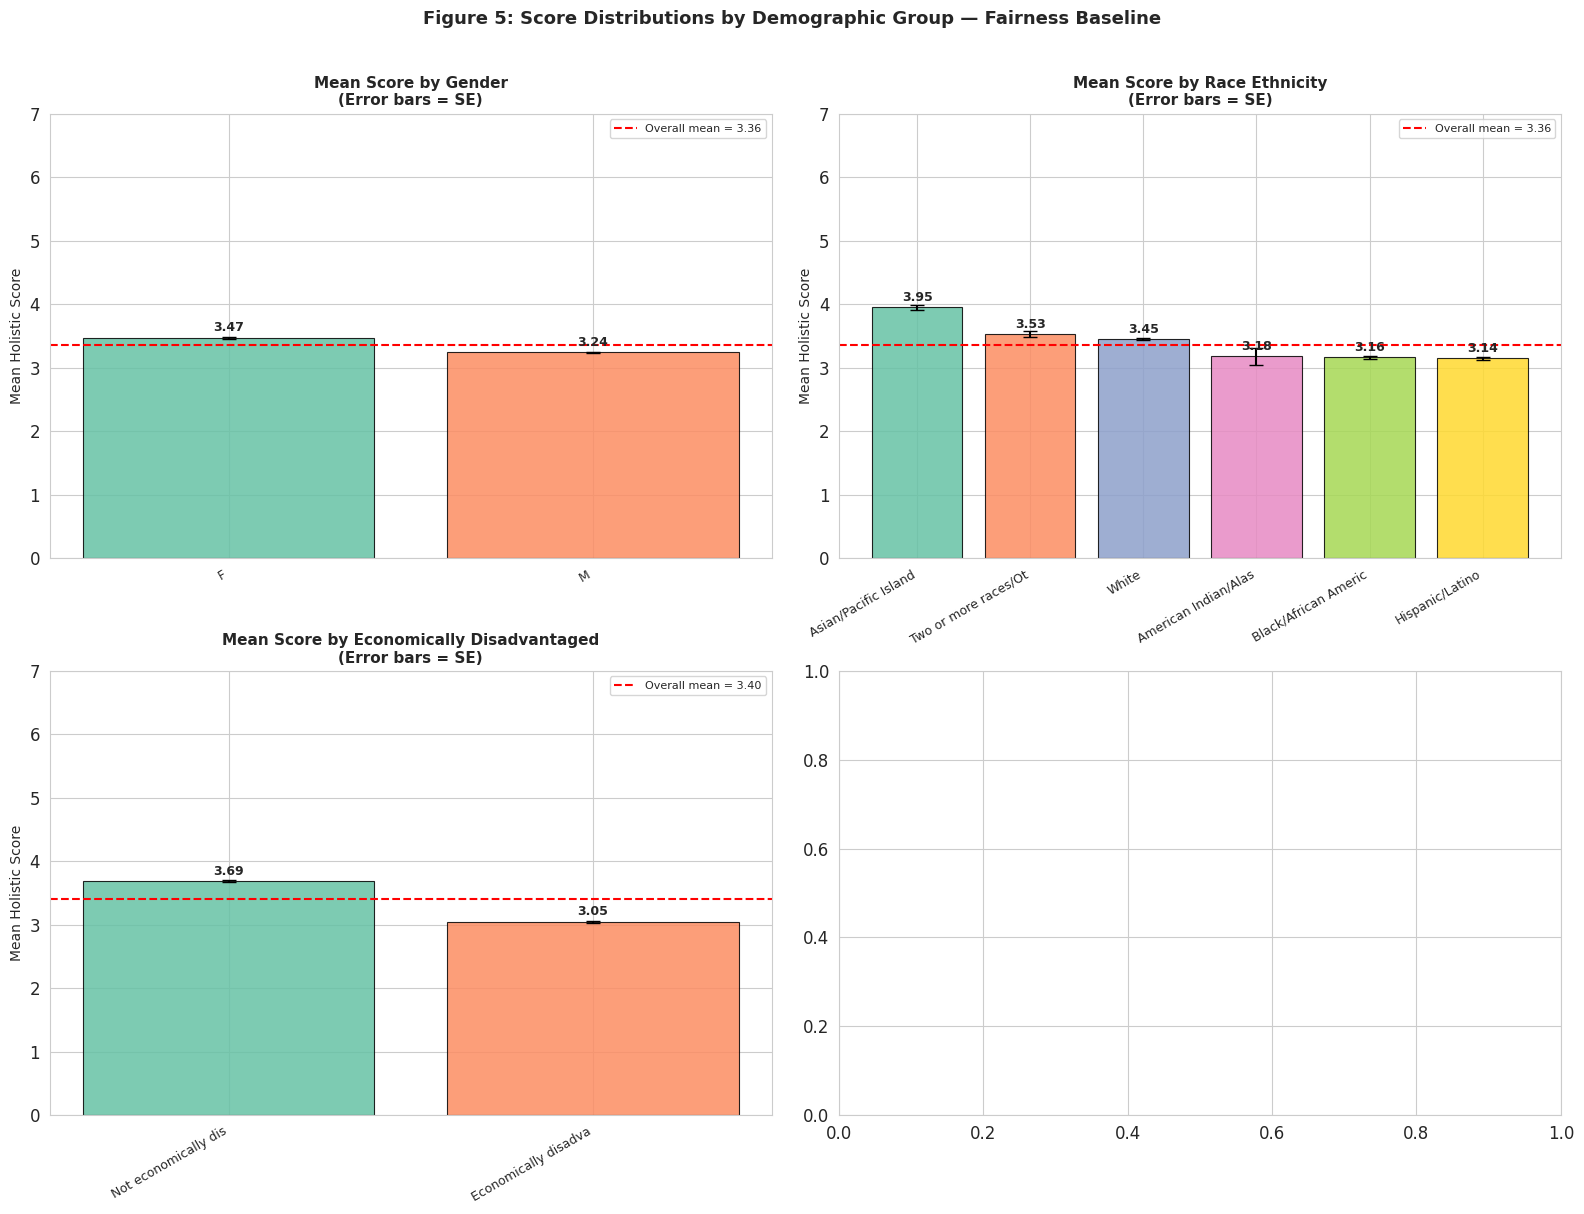

 Saved: fig5_demographic_scores.png


In [23]:
# ── CELL 16: Score by Demographic Groups ────────────────────────────────────
# Critical for fairness audit hypothesis in spec Section 6.2

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

demo_to_plot = [c for c in ['gender','race_ethnicity','ELL_status','economically_disadvantaged']
                if c in essays.columns][:4]

for idx, col in enumerate(demo_to_plot):
    sub = essays[[col, 'holistic_essay_score']].dropna()
    groups = sub[col].unique()
    if len(groups) <= 10:
        mean_scores = sub.groupby(col)['holistic_essay_score'].mean().sort_values(ascending=False)
        se_scores = sub.groupby(col)['holistic_essay_score'].sem()

        colors_demo = sns.color_palette('Set2', len(mean_scores))
        bars = axes[idx].bar(range(len(mean_scores)), mean_scores.values,
                             yerr=se_scores[mean_scores.index].values,
                             capsize=5, color=colors_demo, alpha=0.85,
                             edgecolor='black', linewidth=0.8)
        axes[idx].set_xticks(range(len(mean_scores)))
        axes[idx].set_xticklabels([str(g)[:20] for g in mean_scores.index],
                                   rotation=30, ha='right', fontsize=9)
        axes[idx].set_ylabel('Mean Holistic Score', fontsize=10)
        axes[idx].set_title(f'Mean Score by {col.replace("_"," ").title()}\n(Error bars = SE)',
                            fontweight='bold', fontsize=11)
        overall_mean = sub['holistic_essay_score'].mean()
        axes[idx].axhline(y=overall_mean, color='red', linestyle='--',
                          linewidth=1.5, label=f'Overall mean = {overall_mean:.2f}')
        axes[idx].legend(fontsize=8)
        axes[idx].set_ylim(0, 7)
        for bar, val in zip(bars, mean_scores.values):
            axes[idx].text(bar.get_x() + bar.get_width()/2., val+0.1,
                          f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Figure 5: Score Distributions by Demographic Group — Fairness Baseline',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig5_demographic_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: fig5_demographic_scores.png')

---
## SECTION F — DISCOURSE ELEMENT ANALYSIS
### Understanding the gold-standard argument structure labels

In [24]:
# ── CELL 17: Discourse Elements ──────────────────────────────────────────────
if 'discourse_type' in df.columns:
    print('='*60)
    print('DISCOURSE ELEMENT DISTRIBUTION')
    print('='*60)
    print('(These are the gold-standard argument structure labels)')
    print('(Used to operationalise β₁(Construct) in the CIV regression)\n')

    disc_counts = df['discourse_type'].value_counts()
    print(f'Total discourse annotations: {len(df):,}')
    print(f'Unique discourse types: {df["discourse_type"].nunique()}')
    print()
    for dtype, count in disc_counts.items():
        pct = count/len(df)*100
        bar = '█' * int(pct/1.5)
        print(f'  {dtype:<25} {count:>7,} ({pct:.1f}%) {bar}')

    if 'discourse_effectiveness' in df.columns:
        print('\n' + '='*60)
        print('DISCOURSE EFFECTIVENESS DISTRIBUTION')
        print('(This is your proxy for construct quality β₁)')
        print('='*60)
        eff_counts = df['discourse_effectiveness'].value_counts()
        for eff, count in eff_counts.items():
            print(f'  {str(eff):<20} {count:>7,} ({count/len(df)*100:.1f}%)')
else:
    print(' discourse_type column not in this file — check if separate discourse file exists')

DISCOURSE ELEMENT DISTRIBUTION
(These are the gold-standard argument structure labels)
(Used to operationalise β₁(Construct) in the CIV regression)

Total discourse annotations: 173,266
Unique discourse types: 8

  Claim                      50,208 (29.0%) ███████████████████
  Evidence                   45,702 (26.4%) █████████████████
  Unannotated                28,973 (16.7%) ███████████
  Position                   15,419 (8.9%) █████
  Concluding Statement       13,505 (7.8%) █████
  Lead                        9,305 (5.4%) ███
  Counterclaim                5,817 (3.4%) ██
  Rebuttal                    4,337 (2.5%) █

DISCOURSE EFFECTIVENESS DISTRIBUTION
(This is your proxy for construct quality β₁)
  Adequate             113,244 (65.4%)
  Effective             24,583 (14.2%)
  Ineffective            6,462 (3.7%)


---
## SECTION G — BERT TRUNCATION ANALYSIS
### How many essays will be truncated by BERT's 512 token limit?

In [25]:
# ── CELL 18: BERT Token Length Analysis ──────────────────────────────────────
# BERT limit = 512 tokens. Rule of thumb: tokens ≈ words × 1.35

essays['approx_tokens'] = (essays['word_count'] * 1.35).astype(int)

truncation_buckets = [
    (0, 128, '< 128 tokens (very short)'),
    (128, 256, '128-256 tokens'),
    (256, 384, '256-384 tokens'),
    (384, 512, '384-512 tokens (fits BERT)'),
    (512, 768, '512-768 tokens (will be TRUNCATED)'),
    (768, 1024, '768-1024 tokens (heavily truncated)'),
    (1024, 99999, '> 1024 tokens (very long)'),
]

print('='*60)
print('BERT TOKEN LENGTH DISTRIBUTION')
print('512 = BERT hard limit | Head+Tail strategy planned')
print('='*60)
total_truncated = 0
for low, high, label in truncation_buckets:
    mask = (essays['approx_tokens'] >= low) & (essays['approx_tokens'] < high)
    count = mask.sum()
    pct = count/len(essays)*100
    flag = '⚠️ TRUNCATED' if low >= 512 else '✅'
    if low >= 512:
        total_truncated += count
    print(f'  {label:<40} {count:>6,} ({pct:>5.1f}%) {flag}')

print(f'\n TOTAL essays requiring truncation: {total_truncated:,} ({total_truncated/len(essays)*100:.1f}%)')
print(f' Essays that fit within 512 tokens: {len(essays)-total_truncated:,} ({(len(essays)-total_truncated)/len(essays)*100:.1f}%)')
print('\n Mitigation: Head+Tail truncation (first 128 + last 384 tokens)')
print(' preserves thesis statement AND conclusion — most construct-relevant text.')

BERT TOKEN LENGTH DISTRIBUTION
512 = BERT hard limit | Head+Tail strategy planned
  < 128 tokens (very short)                     0 (  0.0%) ✅
  128-256 tokens                              955 (  6.1%) ✅
  256-384 tokens                            3,189 ( 20.5%) ✅
  384-512 tokens (fits BERT)                3,505 ( 22.5%) ✅
  512-768 tokens (will be TRUNCATED)        4,990 ( 32.0%) ⚠️ TRUNCATED
  768-1024 tokens (heavily truncated)       1,950 ( 12.5%) ⚠️ TRUNCATED
  > 1024 tokens (very long)                 1,004 (  6.4%) ⚠️ TRUNCATED

 TOTAL essays requiring truncation: 7,944 (50.9%)
 Essays that fit within 512 tokens: 7,649 (49.1%)

 Mitigation: Head+Tail truncation (first 128 + last 384 tokens)
 preserves thesis statement AND conclusion — most construct-relevant text.


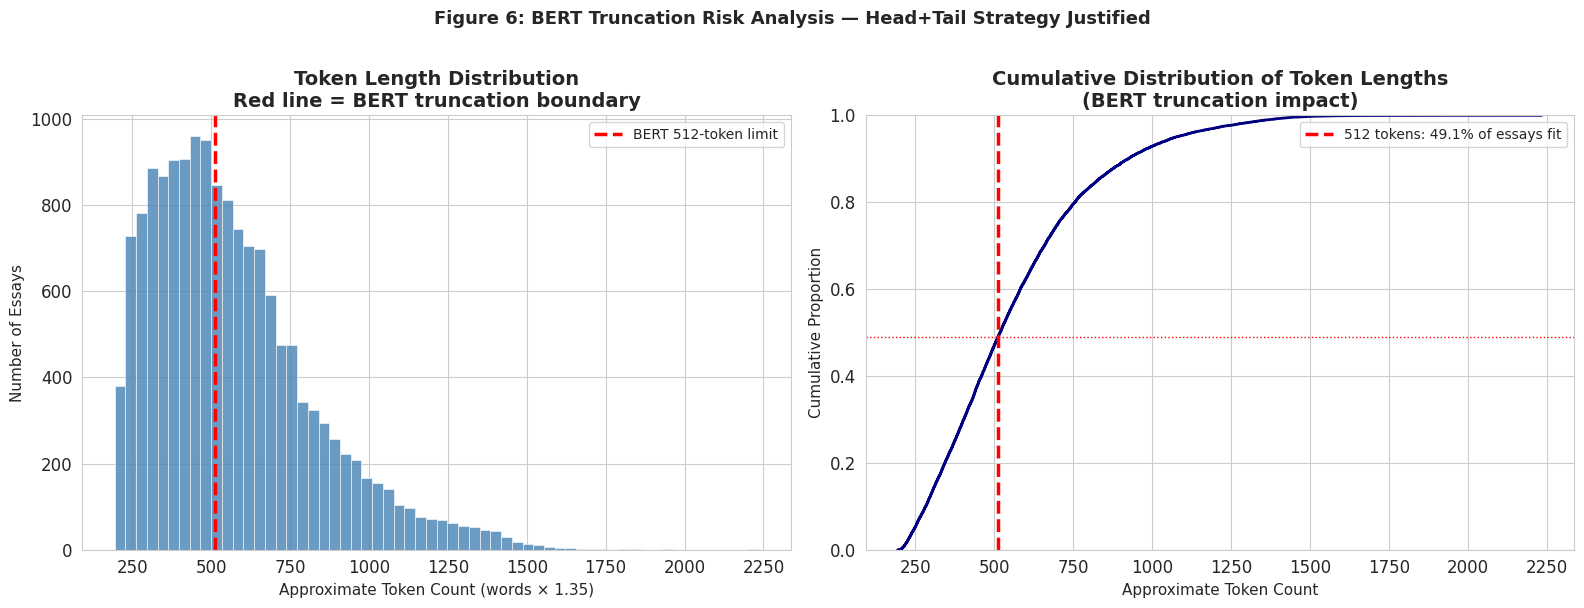

 Saved: fig6_token_lengths.png


In [26]:
# ── CELL 19: Token Length Distribution Plot ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
axes[0].hist(essays['approx_tokens'], bins=60, color='steelblue', edgecolor='white',
             alpha=0.8, linewidth=0.5)
axes[0].axvline(x=512, color='red', linewidth=2.5, linestyle='--',
                label='BERT 512-token limit')
axes[0].set_xlabel('Approximate Token Count (words × 1.35)', fontsize=11)
axes[0].set_ylabel('Number of Essays', fontsize=11)
axes[0].set_title('Token Length Distribution\nRed line = BERT truncation boundary', fontweight='bold')
axes[0].legend(fontsize=10)

# CDF
sorted_tokens = np.sort(essays['approx_tokens'])
cdf = np.arange(1, len(sorted_tokens)+1) / len(sorted_tokens)
axes[1].plot(sorted_tokens, cdf, color='navy', linewidth=2)
pct_under_512 = (essays['approx_tokens'] <= 512).mean() * 100
axes[1].axvline(x=512, color='red', linewidth=2.5, linestyle='--',
                label=f'512 tokens: {pct_under_512:.1f}% of essays fit')
axes[1].axhline(y=pct_under_512/100, color='red', linewidth=1, linestyle=':')
axes[1].set_xlabel('Approximate Token Count', fontsize=11)
axes[1].set_ylabel('Cumulative Proportion', fontsize=11)
axes[1].set_title('Cumulative Distribution of Token Lengths\n(BERT truncation impact)', fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].set_ylim(0, 1)

plt.suptitle('Figure 6: BERT Truncation Risk Analysis — Head+Tail Strategy Justified',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig6_token_lengths.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: fig6_token_lengths.png')

---
## SECTION H — CORRELATION MATRIX & FINAL SUMMARY
### Complete picture of surface features and their relationship to scores

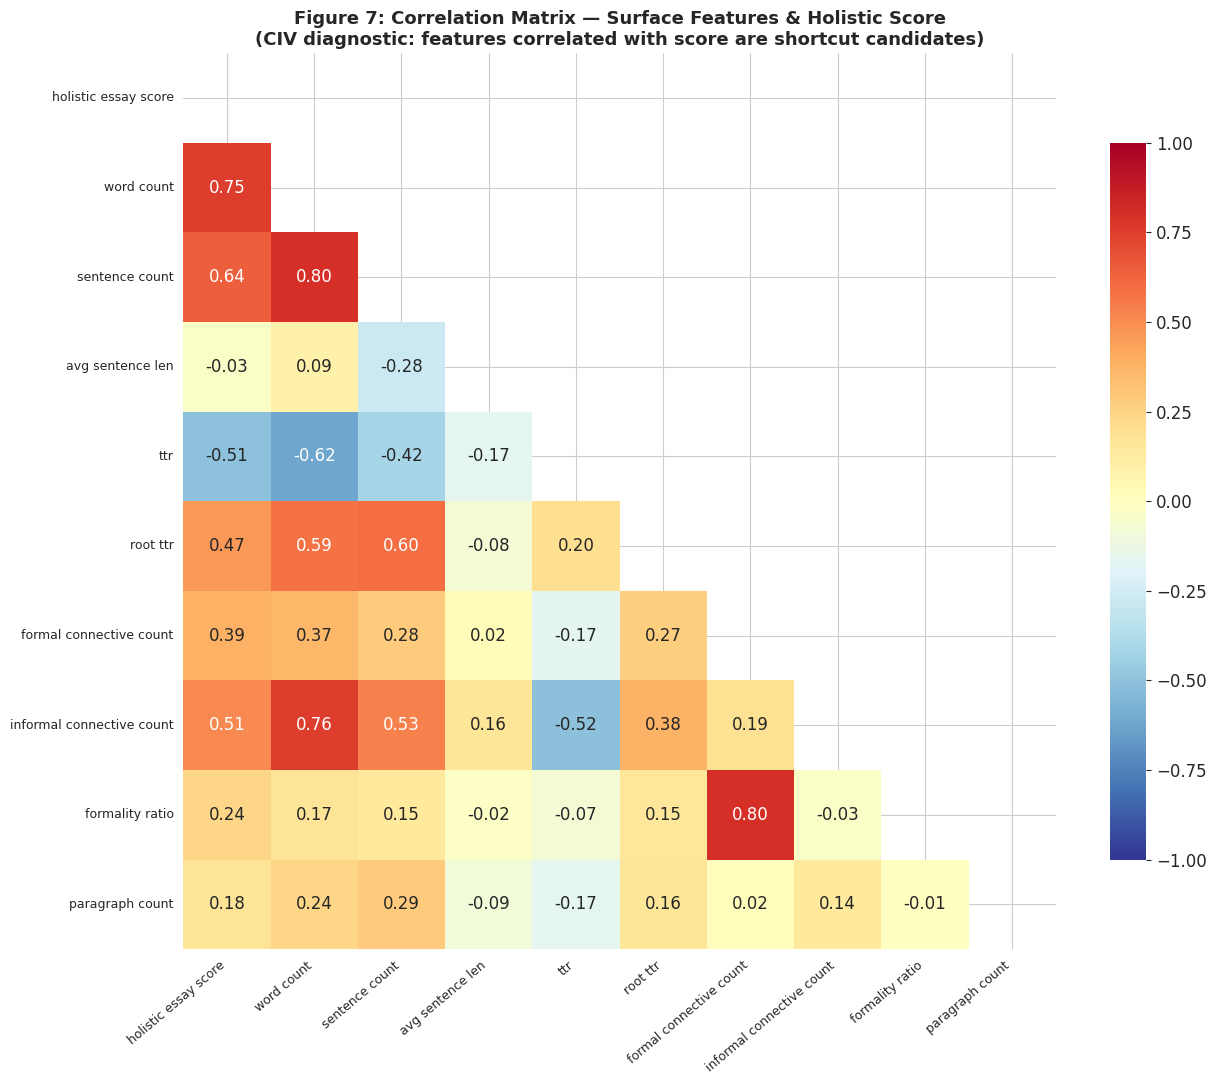

 Saved: fig7_correlation_matrix.png


In [27]:
# ── CELL 20: Full Correlation Matrix ─────────────────────────────────────────
numeric_features = ['holistic_essay_score', 'word_count', 'sentence_count',
                    'avg_sentence_len', 'ttr', 'root_ttr',
                    'formal_connective_count', 'informal_connective_count',
                    'formality_ratio', 'paragraph_count']

available_numeric = [f for f in numeric_features if f in essays.columns]
corr_matrix = essays[available_numeric].corr()

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlBu_r', center=0, vmin=-1, vmax=1,
            ax=ax, cbar_kws={'shrink': 0.8},
            xticklabels=[c.replace('_',' ') for c in corr_matrix.columns],
            yticklabels=[c.replace('_',' ') for c in corr_matrix.index])
ax.set_title('Figure 7: Correlation Matrix — Surface Features & Holistic Score\n'
             '(CIV diagnostic: features correlated with score are shortcut candidates)',
             fontsize=13, fontweight='bold')
plt.xticks(rotation=40, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('fig7_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Saved: fig7_correlation_matrix.png')

In [28]:
# ── CELL 21: FINAL EDA SUMMARY REPORT ────────────────────────────────────────
print('\n' + '='*70)
print('PHASE 1 EDA — COMPLETE SUMMARY REPORT')
print('Dissertation: Construct Validity in Transformer-Based AES')
print('Student ID: 5720570 | University of Warwick')
print('='*70)

print(f'\n DATASET OVERVIEW')
print(f'   Total essays:              {len(essays):,}')
print(f'   Score range:               1–6 (holistic rubric)')
if 'prompt_name' in essays.columns:
    print(f'   Unique prompts:            {essays["prompt_name"].nunique()}')
if 'grade_level' in essays.columns:
    print(f'   Grade levels:              {sorted(essays["grade_level"].dropna().unique().astype(int).tolist())}')
print(f'   Mean word count:           {essays["word_count"].mean():.0f} words')

print(f'\n CIV EVIDENCE SUMMARY')
word_r = correlations["word_count"]["pearson_r"]
print(f'   Word count vs score:  Pearson r = {word_r:.4f}', end=' ')
print(' ABOVE 0.75 THRESHOLD' if abs(word_r) > 0.75 else '📊 Below 0.75 threshold')
print(f'   TTR vs score:         Pearson r = {r_ttr:.4f}')
print(f'   Formality vs score:   Pearson r = {r_form:.4f}')

print(f'\n CLASS IMBALANCE')
for score, count in score_counts.items():
    print(f'   Score {score}: {count:>5,} essays ({count/len(essays)*100:.1f}%)')

print(f'\n BERT TRUNCATION RISK')
trunc_pct = (essays['approx_tokens'] > 512).mean() * 100
print(f'   Essays exceeding 512 tokens: {trunc_pct:.1f}%')
print(f'   Strategy: Head+Tail truncation (128 + 384 tokens)')

print(f'\n PHASE 2 READINESS')
print('    Dataset loaded and validated')
print('    Score distribution documented — stratified split required')
print('    CIV prior evidence established via Pearson r')
print('    TTR and formality metrics computed — perturbation targets identified')
print('    Demographic coverage documented for fairness audit')
print('    BERT truncation risk quantified — mitigation strategy confirmed')
print()
print('NEXT STEPS (Phase 2):')
print('   1. Build train/val/test split (stratified by prompt AND score)')
print('   2. Implement BERT tokenisation + head+tail truncation')
print('   3. Fine-tune BERT-base on PERSUADE 2.0 (target QWK ≥ 0.75)')
print('='*70)


PHASE 1 EDA — COMPLETE SUMMARY REPORT
Dissertation: Construct Validity in Transformer-Based AES
Student ID: 5720570 | University of Warwick

 DATASET OVERVIEW
   Total essays:              15,593
   Score range:               1–6 (holistic rubric)
   Unique prompts:            15
   Grade levels:              [6, 8, 9, 10, 11, 12]
   Mean word count:           421 words

 CIV EVIDENCE SUMMARY
   Word count vs score:  Pearson r = 0.7509  ABOVE 0.75 THRESHOLD
   TTR vs score:         Pearson r = -0.5075
   Formality vs score:   Pearson r = 0.2419

 CLASS IMBALANCE
   Score 1:   610 essays (3.9%)
   Score 2: 3,218 essays (20.6%)
   Score 3: 4,943 essays (31.7%)
   Score 4: 4,193 essays (26.9%)
   Score 5: 2,082 essays (13.4%)
   Score 6:   547 essays (3.5%)

 BERT TRUNCATION RISK
   Essays exceeding 512 tokens: 50.9%
   Strategy: Head+Tail truncation (128 + 384 tokens)

 PHASE 2 READINESS
    Dataset loaded and validated
    Score distribution documented — stratified split required
    C

In [29]:
# ── CELL 22: Save processed dataset for Phase 2 ──────────────────────────────
# Save the enriched essay-level dataframe with all computed features
save_cols = ['essay_id', 'holistic_essay_score', 'word_count', 'sentence_count',
             'avg_sentence_len', 'ttr', 'root_ttr', 'formal_connective_count',
             'informal_connective_count', 'formality_ratio',
             'approx_tokens', 'paragraph_count']

# Add available demographic and prompt columns
for col in ['prompt_name', 'grade_level', 'gender', 'race_ethnicity',
            'economically_disadvantaged', 'ell_status',
            'student_disability_status', 'task']:
    if col in essays.columns:
        save_cols.append(col)

save_cols = [c for c in save_cols if c in essays.columns]
essays_features = essays[save_cols]
essays_features.to_csv('persuade_eda_features.csv', index=False)
essays = essays.rename(columns={
    'ell_status': 'ELL_status',
    'student_disability_status': 'disability_status'
})

print(f'Saved: persuade_eda_features.csv')
print(f'   Rows: {len(essays_features):,}')
print(f'   Columns: {list(essays_features.columns)}')
print()
print('Phase 1 EDA COMPLETE')
print('All figures saved.')

Saved: persuade_eda_features.csv
   Rows: 15,593
   Columns: ['essay_id', 'holistic_essay_score', 'word_count', 'sentence_count', 'avg_sentence_len', 'ttr', 'root_ttr', 'formal_connective_count', 'informal_connective_count', 'formality_ratio', 'approx_tokens', 'paragraph_count', 'prompt_name', 'grade_level', 'gender', 'race_ethnicity', 'economically_disadvantaged', 'ell_status', 'student_disability_status', 'task']

Phase 1 EDA COMPLETE
All figures saved.


In [30]:
print()
print('IMPORTANT for Phase 2: full_text is NOT saved here.')
print('For BERT training, read directly from:')
print(f'  {DATA_PATH}/persuade_corpus_2.0_train.csv')
print('Then merge on essay_id if needed.')


IMPORTANT for Phase 2: full_text is NOT saved here.
For BERT training, read directly from:
  /kaggle/input/datasets/shravaniuk/persuade-corpus-2-0-tarin-test/persuade_corpus_2.0_train.csv
Then merge on essay_id if needed.


In [32]:
# ── CONSTRUCT QUALITY SCORE — β₁ Operationalisation ──────────────────────
# Spec Section 5.2.2: β₁(Construct) in the CIV regression
# Strategy: proportion of EFFECTIVE discourse elements per essay
# NaN (Unannotated) rows are excluded from denominator — they are
# deliberately unrated segments, not missing data.

# Map effectiveness to numeric
eff_map = {'Effective': 2, 'Adequate': 1, 'Ineffective': 0}
df['effectiveness_score'] = df['discourse_effectiveness'].map(eff_map)

# Aggregate per essay — ignoring NaN rows automatically
construct_scores = df.groupby('essay_id').apply(
    lambda g: pd.Series({
        'n_annotated':    g['effectiveness_score'].notna().sum(),
        'n_effective':    (g['discourse_effectiveness'] == 'Effective').sum(),
        'n_adequate':     (g['discourse_effectiveness'] == 'Adequate').sum(),
        'n_ineffective':  (g['discourse_effectiveness'] == 'Ineffective').sum(),
        'n_unannotated':  g['discourse_effectiveness'].isna().sum(),
        'construct_score': (g['effectiveness_score'].mean()  # 0-2 scale
                            if g['effectiveness_score'].notna().any() else np.nan),
        'pct_effective':  ((g['discourse_effectiveness'] == 'Effective').sum() /
                           g['effectiveness_score'].notna().sum()
                           if g['effectiveness_score'].notna().any() else np.nan)
    })
).reset_index()

print('='*60)
print('CONSTRUCT QUALITY SCORE — β₁(Construct) OPERATIONALISED')
print('='*60)
print(f'\nEssays with construct score computed: {construct_scores["construct_score"].notna().sum():,}')
print(f'Essays with NO annotated segments:   {construct_scores["construct_score"].isna().sum():,}')
print(f'\nConstruct score range: {construct_scores["construct_score"].min():.3f} – {construct_scores["construct_score"].max():.3f}')
print(f'Mean construct score:  {construct_scores["construct_score"].mean():.3f}')
print(f'Mean pct_effective:    {construct_scores["pct_effective"].mean():.3f}')

print('\nConstruct score vs holistic score correlation:')
merged = essays.merge(construct_scores[['essay_id','construct_score','pct_effective']], on='essay_id')
r_construct, p_construct = stats.pearsonr(
    merged['construct_score'].dropna(),
    merged.loc[merged['construct_score'].notna(), 'holistic_essay_score']
)
print(f'construct_score vs holistic_score: Pearson r = {r_construct:.4f}')
print(f'This confirms construct_score is a VALID proxy for essay quality (β₁).')

# Save construct scores for Phase 2 regression
construct_scores.to_csv('construct_scores_per_essay.csv', index=False)
print(f'\nSaved: construct_scores_per_essay.csv')
print('This file provides β₁(Construct) for the CIV regression in Phase 4.')

CONSTRUCT QUALITY SCORE — β₁(Construct) OPERATIONALISED

Essays with construct score computed: 15,593
Essays with NO annotated segments:   0

Construct score range: 0.000 – 2.000
Mean construct score:  1.087
Mean pct_effective:    0.151

Construct score vs holistic score correlation:
construct_score vs holistic_score: Pearson r = 0.6647
This confirms construct_score is a VALID proxy for essay quality (β₁).

Saved: construct_scores_per_essay.csv
This file provides β₁(Construct) for the CIV regression in Phase 4.
